# CS564 Assignment 1: Decision Tree Classifier on Iris Dataset
## Roll No:  2201EE54



## Objective
The goal is to implement a Decision Tree Classifier from scratch, evaluate it on the Iris dataset, and analyze how impurity criteria and tree depth affect performance.


## Load Dataset

In [2]:
pip install scikit-learn pandas matplotlib seaborn

     ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
      --------------------------------------- 0.1/8.9 MB 3.6 MB/s eta 0:00:03
     -- ------------------------------------- 0.5/8.9 MB 6.3 MB/s eta 0:00:02
     ----- ---------------------------------- 1.2/8.9 MB 9.3 MB/s eta 0:00:01
     ------- -------------------------------- 1.7/8.9 MB 9.9 MB/s eta 0:00:01
     --------- ------------------------------ 2.1/8.9 MB 9.7 MB/s eta 0:00:01
     ----------- ---------------------------- 2.5/8.9 MB 9.5 MB/s eta 0:00:01
     ------------- -------------------------- 3.0/8.9 MB 9.6 MB/s eta 0:00:01
     -------------- ------------------------- 3.3/8.9 MB 9.2 MB/s eta 0:00:01
     ---------------- ----------------------- 3.7/8.9 MB 9.1 MB/s eta 0:00:01
     ------------------ --------------------- 4.1/8.9 MB 9.4 MB/s eta 0:00:01
     -------------------- ------------------- 4.5/8.9 MB 8.9 MB/s eta 0:00:01
     ---------------------- ----------------- 4.9/8.9 MB 8.9 MB/s eta 0


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
import math

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv(url, header=None, names=columns)
df.dropna(inplace=True)

# Encode class labels to integers
df['class'] = df['class'].astype('category').cat.codes
df.head()


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
df['class'].describe()

count    150.000000
mean       1.000000
std        0.819232
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        2.000000
Name: class, dtype: float64

In [ ]:
df['class'].value_counts() # they are the setosa, versicolor, virginica

class
0    50
1    50
2    50
Name: count, dtype: int64

## Decision Tree Classifier from Scratch

In [4]:
class DecisionTreeClassifierScratch:
    def __init__(self, criterion='gini', max_depth=None, min_samples_split=2):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(np.array(X), np.array(y), depth=0)

    def predict(self, X):
        return [self._predict_single(self.tree, sample) for sample in X]

    def print_tree(self, node=None, indent=""):
        if node is None:
            node = self.tree
        if isinstance(node, dict):
            print(f"{indent}[X{node['feature']} <= {node['threshold']:.3f}]")
            self.print_tree(node['left'], indent + "  ")
            self.print_tree(node['right'], indent + "  ")
        else:
            print(f"{indent}Predict: {node}")

    def _predict_single(self, node, sample):
        if isinstance(node, dict):
            if sample[node['feature']] <= node['threshold']:
                return self._predict_single(node['left'], sample)
            else:
                return self._predict_single(node['right'], sample)
        else:
            return node

    def _build_tree(self, X, y, depth):
        if len(set(y)) == 1:
            return y[0]
        if self.max_depth is not None and depth >= self.max_depth:
            return self._majority_class(y)
        if len(y) < self.min_samples_split:
            return self._majority_class(y)

        feature, threshold = self._best_split(X, y)

        if feature is None or threshold is None:
            return self._majority_class(y)

        left_idx = X[:, feature] <= threshold
        right_idx = ~left_idx

        if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:
            return self._majority_class(y)


        return {
            'feature': feature,
            'threshold': threshold,
            'left': self._build_tree(X[left_idx], y[left_idx], depth + 1),
            'right': self._build_tree(X[right_idx], y[right_idx], depth + 1)
        }


    def _majority_class(self, y):
        return Counter(y).most_common(1)[0][0]

    def _best_split(self, X, y):
        best_gain = -1
        best_feature, best_threshold = None, None
        n_features = X.shape[1]
        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for t in thresholds:
                gain = self._information_gain(y, X[:, feature], t)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = t
        return best_feature, best_threshold

    def _information_gain(self, y, feature_column, threshold):
        parent_loss = self._impurity(y)
        left_mask = feature_column <= threshold
        right_mask = ~left_mask
        if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
            return 0
        n = len(y)
        left_loss = self._impurity(y[left_mask])
        right_loss = self._impurity(y[right_mask])
        weighted_avg = len(y[left_mask]) / n * left_loss + len(y[right_mask]) / n * right_loss
        return parent_loss - weighted_avg

    def _impurity(self, y):
        counts = np.bincount(y)
        probs = counts / len(y)
        if self.criterion == 'gini':
            return 1 - np.sum(probs ** 2)
        elif self.criterion == 'entropy':
            return -np.sum([p * math.log2(p) for p in probs if p > 0])
        elif self.criterion == 'misclassification':
            return 1 - np.max(probs)
        else:
            raise ValueError("Unknown criterion")

## Model Evaluation

In [5]:

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def evaluate_model(criterion):
    clf = DecisionTreeClassifierScratch(criterion=criterion, max_depth=None)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"--- Evaluation for {criterion.upper()} ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    return accuracy_score(y_test, y_pred)


## GINI Impurity Evaluation

In [6]:
X = df.drop('class', axis=1).values
y = df['class'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf_gini = DecisionTreeClassifierScratch(criterion='gini', max_depth=None)
clf_gini.fit(X_train, y_train)
y_pred_gini = clf_gini.predict(X_test)

print(f"----- Evaluation for GINI ----")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gini))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gini, zero_division=0))
acc_gini = accuracy_score(y_test, y_pred_gini)
print("Accuracy:", acc_gini)
print("\nGINI Tree Structure:")
clf_gini.print_tree()

----- Evaluation for GINI ----
Confusion Matrix:
[[19  0  0]
 [ 0 11  2]
 [ 0  0 13]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.85      0.92        13
           2       0.87      1.00      0.93        13

    accuracy                           0.96        45
   macro avg       0.96      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45

Accuracy: 0.9555555555555556

GINI Tree Structure:
[X2 <= 1.900]
  Predict: 0
  [X2 <= 4.700]
    [X3 <= 1.500]
      Predict: 1
      Predict: 2
    [X3 <= 1.700]
      [X2 <= 4.900]
        Predict: 1
        [X3 <= 1.500]
          Predict: 2
          [X0 <= 6.700]
            Predict: 1
            Predict: 2
      [X2 <= 4.800]
        [X0 <= 5.900]
          Predict: 1
          Predict: 2
        Predict: 2


## Entropy Evaluation

In [7]:
clf_entropy = DecisionTreeClassifierScratch(criterion='entropy', max_depth=None)
clf_entropy.fit(X_train, y_train)
y_pred_entropy = clf_entropy.predict(X_test)

print(f"\n--- Evaluation for ENTROPY ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_entropy))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_entropy, zero_division=0))
acc_entropy = accuracy_score(y_test, y_pred_entropy)
print("Accuracy:", acc_entropy)
print("\nEntropy Tree Structure:")
clf_entropy.print_tree()


--- Evaluation for ENTROPY ---
Confusion Matrix:
[[19  0  0]
 [ 0 11  2]
 [ 0  2 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.85      0.85      0.85        13
           2       0.85      0.85      0.85        13

    accuracy                           0.91        45
   macro avg       0.90      0.90      0.90        45
weighted avg       0.91      0.91      0.91        45

Accuracy: 0.9111111111111111

Entropy Tree Structure:
[X2 <= 1.900]
  Predict: 0
  [X2 <= 4.700]
    [X3 <= 1.500]
      Predict: 1
      Predict: 2
    [X2 <= 5.100]
      [X3 <= 1.700]
        [X1 <= 2.200]
          Predict: 2
          [X2 <= 5.000]
            Predict: 1
            [X0 <= 6.000]
              Predict: 1
              Predict: 2
        [X1 <= 3.000]
          Predict: 2
          Predict: 1
      Predict: 2


## Misclassification Error Evaluation

In [8]:
clf_misclassification = DecisionTreeClassifierScratch(criterion='misclassification', max_depth=None)
clf_misclassification.fit(X_train, y_train)
y_pred_misclassification = clf_misclassification.predict(X_test)

print(f"\n--- Evaluation for MISCLASSIFICATION ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_misclassification))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_misclassification, zero_division=0))
acc_misclassification = accuracy_score(y_test, y_pred_misclassification)
print("Accuracy:", acc_misclassification)
print("\nMisclassification Error Tree Structure:")
clf_misclassification.print_tree()


--- Evaluation for MISCLASSIFICATION ---
Confusion Matrix:
[[19  0  0]
 [ 0 12  1]
 [ 0  2 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.86      0.92      0.89        13
           2       0.92      0.85      0.88        13

    accuracy                           0.93        45
   macro avg       0.92      0.92      0.92        45
weighted avg       0.93      0.93      0.93        45

Accuracy: 0.9333333333333333

Misclassification Error Tree Structure:
[X2 <= 3.800]
  [X2 <= 1.900]
    Predict: 0
    Predict: 1
  [X2 <= 4.700]
    [X0 <= 4.900]
      Predict: 2
      Predict: 1
    [X0 <= 5.800]
      Predict: 2
      [X0 <= 6.800]
        [X1 <= 3.300]
          [X0 <= 6.200]
            [X1 <= 3.000]
              [X0 <= 5.900]
                Predict: 2
                Predict: 2
              Predict: 1
            [X1 <= 2.500]
              Predict: 1
              [

## Effect of Tree Depth

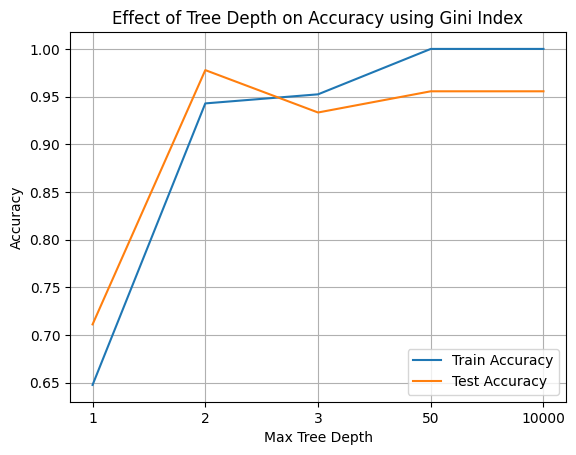

In [10]:

depths = [1, 2, 3, 50, 10000]
train_acc = []
test_acc = []

for d in depths:
    clf = DecisionTreeClassifierScratch(criterion='gini', max_depth=d)
    clf.fit(X_train, y_train)
    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)
    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))

plt.plot([str(d) for d in depths], train_acc, label='Train Accuracy')
plt.plot([str(d) for d in depths], test_acc, label='Test Accuracy')
plt.xlabel('Max Tree Depth')
plt.ylabel('Accuracy')
plt.title('Effect of Tree Depth on Accuracy using Gini Index')
plt.legend()
plt.grid(True)
plt.show()


# Part D: Analysis and Discussion


## 1. Which impurity measure provided the best classification performance?

Based on the evaluation metrics from the test set, the Gini impurity criterion yielded the best-performing model.

Gini Accuracy: 95.6%
Misclassification Error Accuracy: 93.3%
Entropy Accuracy: 91.1%

The model using the Gini index not only achieved the highest overall accuracy but also demonstrated strong performance across all classes, as seen in its classification report. It perfectly classified all instances of class '0' and achieved a high F1-score for the other two classes (0.92 and 0.93).


## 2. Impact of Tree Depth on Generalization

Low Depth (e.g., 1, 2): At shallow depths, the model is simple and has high bias. It cannot capture the complexity of the data, leading to underfitting. This results in lower accuracy on both the training and testing sets because the decision boundaries are too simplistic.

Increasing Depth (e.g., 3, 5): As the tree grows deeper, it learns more specific patterns from the training data. This reduces bias, and consequently, both training and test accuracy increase. The model's ability to generalize improves as it learns more relevant features and interactions.

Large Depth: When the depth is a very large number, the model becomes highly complex. This results in the training accuracy approaching 100% but risks overfitting. The model starts learning noise and outliers specific to the training set. This causes the test accuracy to decrease.

## 3. Optimal Tree Depth

The test accuracy likely increases significantly from a depth of 1 to 3 or 5 and then plateaus. The unlimited-depth Gini model achieved an accuracy of 95.6%. A simpler model with a max_depth of 3 to 5 would likely achieve a comparable test accuracy.

Choosing a slightly shallower tree (e.g., depth 5) over an unconstrained one is often preferable. A simpler model is more interpretable and less likely to be overfit to the specific training data, meaning it may perform more consistently on new, unseen data. Therefore, an optimal depth of around 3 to 5 appears to be the most reasonable choice, as it effectively balances model complexity (variance) and its ability to capture the underlying data patterns (bias).


1) best impurity measure

Gini gave the top test performance.

Accuracy: Gini 95.6%, Misclassification Error 93.3%, Entropy 91.1%.

Gini report: class ‘0’ perfectly classified; other classes F1 = 0.92, 0.93.

2) tree depth vs generalization

Low depth (1–2): high bias, underfit → low train/test accuracy.

Moderate (3–5): learns key patterns, lower bias → both accuracies rise.

Unlimited (max_depth=None / very large): overfits; train ≈ 100%, test plateaus or drops.

3) optimal depth

Test accuracy jumps from 1 → 3–5, then levels off.

Unlimited-depth Gini = 95.6%; depth 3–5 likely similar.

Pick ~5 (or 3–5): simpler, more interpretable, less overfit; solid bias–variance balance.